In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.optimize import fsolve

In [2]:
k = 8.61733e-5; # boltzmann constant in eV/K
k_j = 1.3806e-23 #boltzmann constant in J/K
R = 8.314 #J/Mol*K
e = 1.6e-19
TK = 1150+273; # equilibrium temp in K
TC = TK-273; # equilibrium temp in C
TQK = 500+273;# quenched temp in K
TQC = TQK-273; # quenched temp in C
a = np.logspace(-20,5,50); # oxygen partial pressure range
# a = 0.2
# h = np.logspace(-20,4,50) # water vapor partial pressure

#names = ["Cacc","Cacc_1","Cyt_1","CVO2","CVO2_1","CVTi4","CVTi4_1","CVBa2","CVBa2_1","n","nq","p","pq"]
#df = pd.DataFrame(columns = names) #create pandas df for data storage

In [3]:
M = np.zeros(len(a)); # definding vectors to fill in with values later
Cacc = np.zeros(len(a))
Cacc_1 = np.zeros(len(a))
Cyt_1 = np.zeros(len(a))
CVO2 = np.zeros(len(a))
CVO2_1 = np.zeros(len(a))
CVTi4 = np.zeros(len(a))
CVTi4_1 = np.zeros(len(a))
CVBa2 = np.zeros(len(a))
CVBa2_1 = np.zeros(len(a))
n = np.zeros(len(a))
nq = np.zeros(len(a))
p = np.zeros(len(a))
pq = np.zeros(len(a))

In [4]:
un = 8080*(TQK**(-3/2))*np.exp(-0.021/(k*TQK)) # mobility of electron
up = un/2 # monbility of hole
uVO = (52/TQK)*np.exp(-0.84/(k*TQK)) # mobility of oxygen vacancy

In [5]:
Cmgt_1 = 1*7.65E+19 # single-vaelnt Mg concentration = 0.5mol%
Cacc_1 = 5E18 # unintentionally doped single-valent acceptor concentration
#C_Hydrogen_1 = 1.64E18 #unintentionally doped single-valent donor concentration - hydrogen from humidity testing
#Cyt_1 =0 #1*7.65E+19  # single-valent Y concentration = 0.5mol%

In [6]:
# KR = 2.40E74*np.exp(-5.88/(k*TK)) # K for the reduction reaction in cm-9atm^1/2 published in J. Nowotny and M. Rekas, “Defect structure, electrical properties and transport in Barium Titanate. VI. General defect model,?Ceram. Int., 20 [4] 257?63 (1994).
KR = 1.06E71*np.exp(-5.69/(k*TK)) #undoped BaTiO3 
# Ki = 6.8E44*np.exp(-2.90/(k*TK)) # K for the intrisic equailibirum in cm-6 published in C.-R. SONG, H.-I. YOO, and J.-Y. KIM, “Mn-doped BaTiO3: Electrical Transport Properties in Equilibrium State,?J. Electroceramics, 1 [1] 27?9 (1997).
Ki = 8.55E44*np.exp(-2.91/(k*TK))
#KS = (10**116)*np.exp(-10.5/((k*TK))) # K for the Schottky reaction in cm-15 from S. H. Yoon, K. H. Lee, and H. Kim, J. Am. Ceram. Soc. 83,2463 Íì2000? #for donor doped BTO
KS = (3.4E105)*np.exp(-2.795/(k*TK)) #acceptor and nominally undoped BaTiO3
#Khydr_mol = 8.1*10**-9 #WASER, R. (1988). Solubility of Hydrogen Defects in Doped and Undoped BaTiO3. Journal of the American Ceramic Society, 71(1), 58–63. https://doi.org/10.1111/j.1151-2916.1988.tb05760.x
# delS = -97.5
# delH = -21700

In [11]:
KPSB = (1.15E22)**2*np.exp(10.15)*np.exp(-2.32/(k*TK))
KPST = (1.15E22)**3*np.exp(8.06)*np.exp(-2.89/(k*TK))
KFS = (1.15E22)**5*np.exp(10)*np.exp(-3.48/(k*TK))
print(KPSB)
print(KPST)
print(KPSB*KPST)
print(KFS)

2.055118526255266e+40
2.799715382007209e+59
5.753746949804854e+99
2.0963429110564428e+102


In [9]:
print(KS)

4.2908498341660967e+95


In [65]:
print((1.15E22)**5*np.exp(10)*np.exp(-3.48/(k*TK)))

2.0963429110564428e+102


In [66]:
print(6.02/233.19*6.022E23)

1.5546309876066726e+22


In [16]:
#for changing partial oxygen pressure
for i in range(len(a)): # This part is for obtaining a full equilibirum defect structure at TK(TC)
    y = a[i] #oxygen pressure atm
    #x = Symbol('x', real = True) # a number of electron, n, which is defined as a variable, x
    #CVO2_1 = (KR/(x**2)*(y**(-1/2))) # a converted form of oxygen vacancies
    #CVTi4_1 = (KS/(KR**3))**(1/2)*x**3*(y**(3/4)); # a converted form of cation vacancies
    def f(x):
        # return (x + 2*KPT/(KR/((x**2)*(y**1/2))) + 4*(KS/KPT)*(((x**2)*(y**1/2))/KR)**2 - (Ki/x) - 2*KR/((x**2)*(y**(1/2))))
        # return (x + 6*(KS/(KR**3))**(1/2)*x**3*(y**(3/4)) - (Ki/x) - 2*(KR/(x**2)*(y**(-1/2))))
        return (x + 6*(KPSB*KPST/(KR**3))**(1/2)*x**3*(y**(3/4)) - (Ki/x) - 2*(KR/(x**2)*(y**(-1/2))))
        # return (x + 2*Cmgt_1 + Cacc_1 + 6*(KS/(KR**3))**(1/2)*x**3*(y**(3/4)) - (Ki/x) - 2*(KR/(x**2)*(y**(-1/2))))
        # return (x + 2*Cmgt_1 + Cacc_1 - (Ki/x) - 2*(KR/(x**2)*(y**(-1/2))))
    # eqn1 = x + 2*Cmgt_1 + Cacc_1 + 6*CVTi4_1 - (Ki/x) - 2*CVO2_1 - Cyt_1 # the total charge nuetrality equation
    # f = implemented_function('f', lambda x: eqn1)
    # fn1 = lambdify(x, f(x))
    sol1 = brentq(f,1,1E30)
    # sol1 = fsolve(f,1E15)
    # sol1 = solveset(eqn1,x,domain=S.Reals)
    n[i] = np.array(sol1).astype(np.float64) # a concentration of electron
    CVO2[i] = KR/(n[i]**2)*(y**(-1/2)); # a concentration of oxygen vacancies (Reduction reaction)
    # CVBa2[i] = KPT/(KR/n[i]**2*y**1/2)
    # CVO2_1[i] = KPT/CVBa2[i]
    # CVTi4[i] = KS/KPT*(n[i]**2*y**1/2/KR)**2
    CVTi4[i] = ((KPSB*KPST/(KR**3))**(1/2))*(n[i]**3)*(y**(3/4)) # a concentration of cation vacancies (Schottky reaction)

In [83]:
for i in range(len(a)):
    y = a[i] # log(oxygen partial pressure in atm)
    def f(x): # x = oxygen vacancy concentration
        return (Ki/(KR/(x*y**1/2))**1/2 + 2*x - (KR/(x*y**1/2))**1/2 - 2*KPT/x - 4*KPB/(x**2))
    sol1 = brentq(f,1,1E40)
    CVO2[i] = np.array(sol1).astype(np.float64)
    n[i] = (KR/(CVO2[i]*y**1/2))**1/2
    CVBa2[i] = KPT/CVO2[i]
    CVTi4[i] = KPB/CVO2[i]


In [93]:
for i in range(len(a)):
    y = a[i] # log(oxygen partial pressure in atm)
    def f(x):# x = electron concentration
        return (x + 2*(KPT/KR)*(x**2)*(y**1/2) + 4*(KPB/(KR**2))*(x**4)*y - (Ki/x) - 2*KR/((x**2)*(y**1/2)))
    sol1 = brentq(f,1,1E30)
    n[i] = np.array(sol1).astype(np.float64) # a concentration of electron
    CVO2[i] = KR/((n[i]**2)*(y**1/2))
    CVBa2[i] = (KPT/KR)*(n[i]**2)*(y**1/2)
    CVTi4[i] = (KPB/(KR**2))*(n[i]**4)*y


RuntimeError: Failed to converge after 100 iterations.

/tmp/ipykernel_1816/1558039811.py:21: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CVBa2),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2+}$')


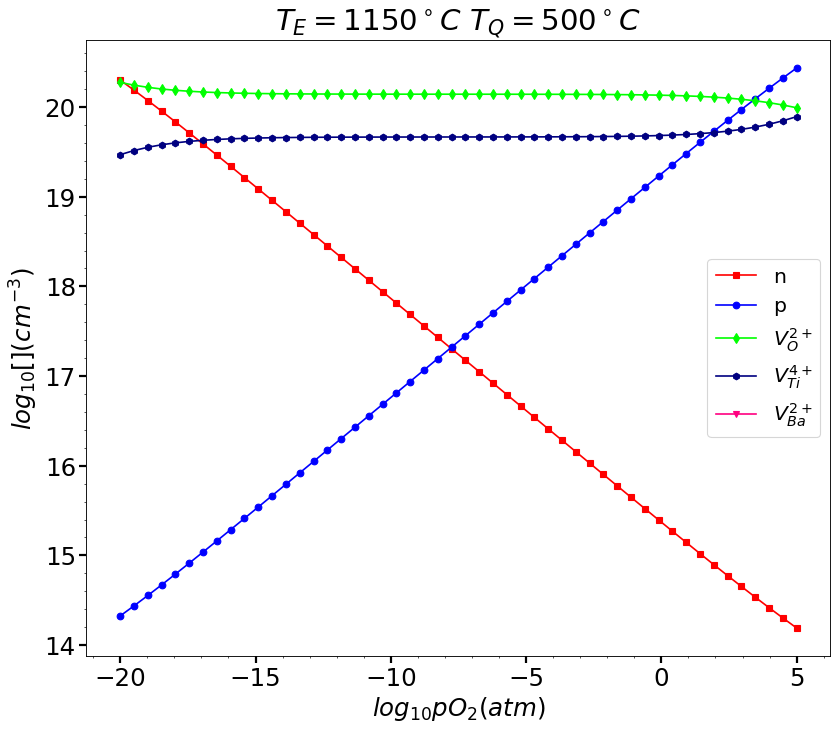

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

fig = plt.figure(figsize=(12, 10), dpi=80)
ax1= plt.subplot(111)
# plt.yscale('symlog',subsy=[2, 3, 4, 5, 6, 7, 8, 9])
ax1.set_title(r"$T_E = $" +str(TC)+"$^\circ C\/\/T_Q = $" +str(TQC) +"$^\circ C $")
# ax1.set_ylim(ymin=0, ymax=1.5E6)
# ax1.set_xlim(xmin=0, xmax=) # set x limits if needed
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(Ki/n),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
# ax1.plot(np.log10(a),np.log10(Cacc),marker='v', c =[255/255, 0/255, 255/255], label = r'$A_{Ti}^{1-}$') 
# ax1.plot(np.log10(a),np.log10(Cmgt),marker='+', c =[0/255, 255/255, 255/255], label = r'$Mg_{Ti}^{2-}$')
# ax1.plot(np.log10(a),np.log10(Cyt),marker='*', c =[0/255, 0/255, 0/255], label = r'$Y_{Ba}^{1+}$' )
ax1.plot(np.log10(a),np.log10(CVTi4),marker='h', c =[0/255, 0/255, 128/255], label = r'$V_{Ti}^{4+}$')
ax1.plot(np.log10(a),np.log10(CVBa2),marker='v', c =[255/255, 0/255, 128/255], label = r'$V_{Ba}^{2+}$')
# ax1.plot(np.log10(a),np.log10(COHO),marker='s', c =[128/255, 0/255, 128/255], label = r'$H^{1+}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc='best',fontsize='small')